In [ ]:
from google.colab import files
uploaded = files.upload()
! unzip -o brain_tumor_dataset.zip
!mkdir dataset
!mv yes dataset/
!mv no dataset/
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

dataset_path = "/content/dataset"

Saving brain_tumor_dataset.zip to brain_tumor_dataset (1).zip
Archive:  brain_tumor_dataset.zip
  inflating: no/1 no.jpeg            
  inflating: no/10 no.jpg            
  inflating: no/11 no.jpg            
  inflating: no/12 no.jpg            
  inflating: no/13 no.jpg            
  inflating: no/14 no.jpg            
  inflating: no/15 no.jpg            
  inflating: no/17 no.jpg            
  inflating: no/18 no.jpg            
  inflating: no/19 no.jpg            
  inflating: no/2 no.jpeg            
  inflating: no/20 no.jpg            
  inflating: no/21 no.jpg            
  inflating: no/22 no.jpg            
  inflating: no/23 no.jpg            
  inflating: no/24 no.jpg            
  inflating: no/25 no.jpg            
  inflating: no/26 no.jpg            
  inflating: no/27 no.jpg            
  inflating: no/28 no.jpg            
  inflating: no/29 no.jpg            
  inflating: no/3 no.jpg             
  inflating: no/30 no.jpg            
  inflating: no/31 no.jpg     

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)
print("Classes:", train_data.class_indices)

Training samples: 203
Validation samples: 50
Classes: {'no': 0, 'yes': 1}


In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 767ms/step - accuracy: 0.6207 - loss: 0.9040 - val_accuracy: 0.7600 - val_loss: 0.6836
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7980 - loss: 0.6637 - val_accuracy: 0.7400 - val_loss: 0.6186
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7241 - loss: 0.5900 - val_accuracy: 0.7200 - val_loss: 0.5544
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7734 - loss: 0.4860 - val_accuracy: 0.7400 - val_loss: 0.5487
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8128 - loss: 0.4777 - val_accuracy: 0.7200 - val_loss: 0.5702
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8276 - loss: 0.4485 - val_accuracy: 0.7600 - val_loss: 0.5448
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8325 - loss: 0.4295 - val_accuracy: 0.7400 - val_loss: 0.5424
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8522 - loss: 0.3700 - val_accuracy: 0.8000 - val_loss: 0.539

In [ ]:
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7600 - loss: 0.4944
Validation Accuracy: 0.7599999904632568


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step


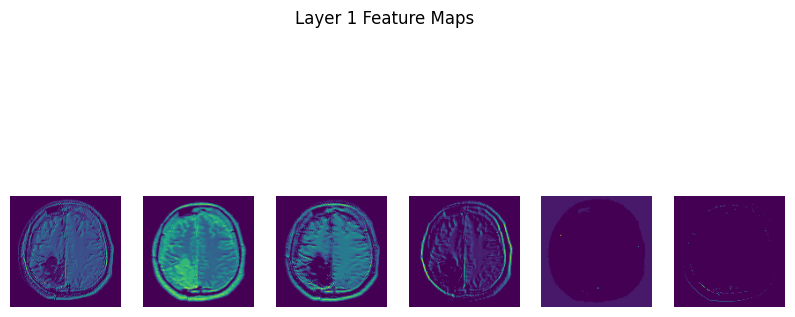

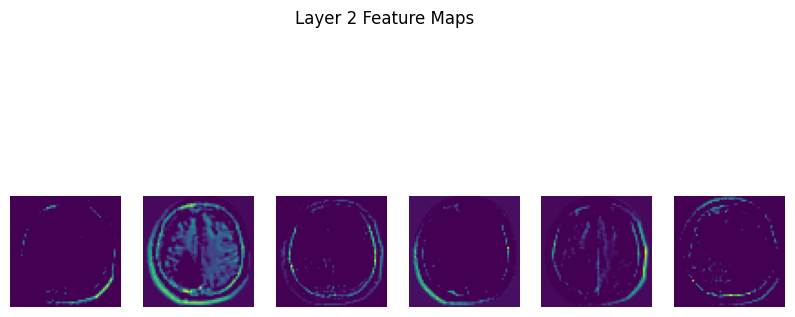

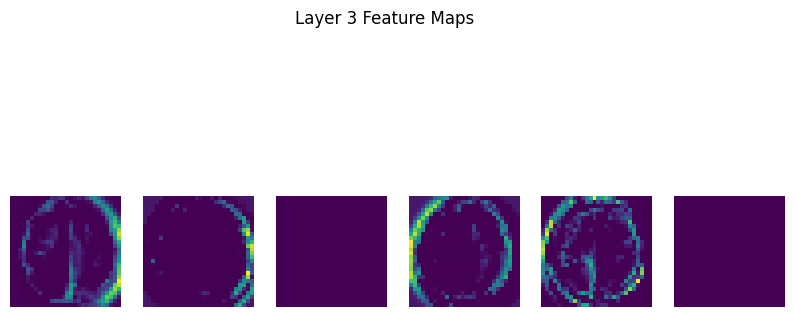

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Tumor Detected


In [ ]:
# Load image
img_path = "/content/test.jpg.jpeg"

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Get conv layer outputs
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

# FIXED LINE
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

activations = activation_model.predict(img_array)

# Plot
for i, activation in enumerate(activations):
    plt.figure(figsize=(10,5))

    for j in range(min(6, activation.shape[-1])):
        plt.subplot(1,6,j+1)
        plt.imshow(activation[0,:,:,j], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Layer {i+1} Feature Maps")
    plt.show()
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

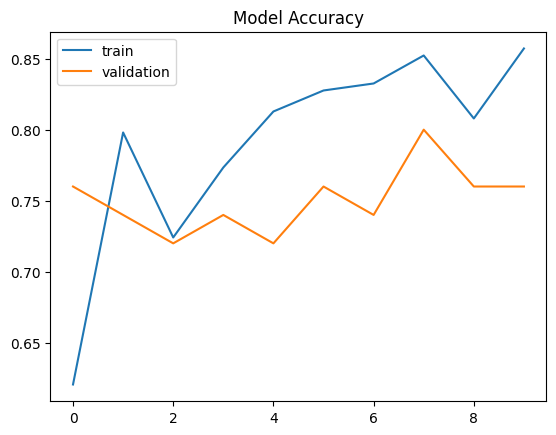

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.title("Model Accuracy")
plt.legend()
plt.show()

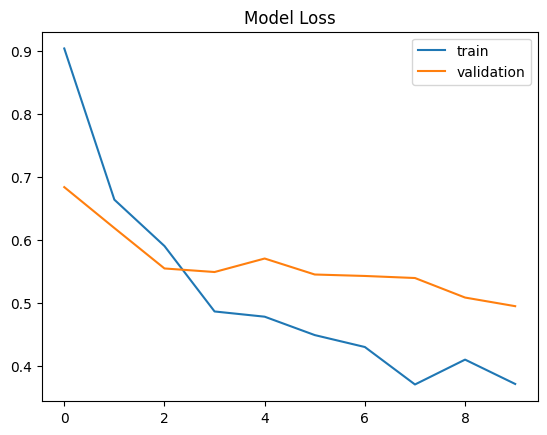

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')

plt.title("Model Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Last Conv Layer: conv2d_2


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


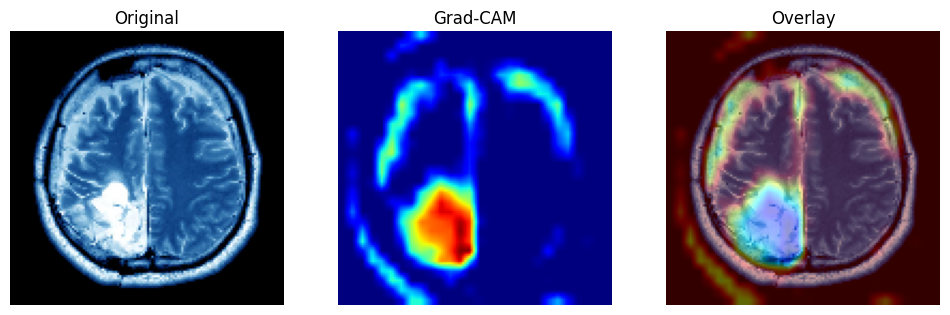

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# Ensure model is built (VERY IMPORTANT)
_ = model.predict(img_array)

# Get last Conv2D layer safely
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("Last Conv Layer:", last_conv_layer)

# Create Grad-CAM model (FIXED)
grad_model = Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer).output,
        model.outputs[0]   # FIXED (instead of model.output)
    ]
)

# Compute gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

# Get gradients
grads = tape.gradient(loss, conv_outputs)

# Global average pooling
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Weight feature maps
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Convert to numpy safely
heatmap = heatmap.numpy()

# Normalize heatmap (FIX: avoid divide by zero)
heatmap = np.maximum(heatmap, 0)
if np.max(heatmap) != 0:
    heatmap /= np.max(heatmap)

# Resize heatmap
heatmap = cv2.resize(heatmap, (128, 128))

# Convert to color
heatmap_colored = np.uint8(255 * heatmap)
heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)

# Load original image
original_img = image.load_img(img_path, target_size=(128,128))
original_img = image.img_to_array(original_img).astype(np.uint8)

# Overlay heatmap
superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap_colored, 0.4, 0)

# Show results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(original_img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Grad-CAM")
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(superimposed_img)
plt.axis('off')

plt.show()

In [ ]:
prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    label = "Tumor Detected"
else:
    label = "No Tumor"

confidence = prediction if prediction > 0.5 else (1 - prediction)

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction: Tumor Detected
Confidence: 0.50
